# Load Libraries & Data


In [640]:
# !pip install statsmodels
# !pip install ta

In [641]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import ta

# Load the CSV file
file_path = "EGX30_2000-2025.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

       Date      Price       Open       High        Low     Vol. Change %
0  2/6/2025  30,011.84  29,735.59  30,011.84  29,735.59   83.50M    0.93%
1  2/5/2025  29,735.59  29,668.47  29,772.63  29,596.50  103.71M    0.23%
2  2/4/2025  29,668.47  29,754.77  29,937.39  29,668.47  135.05M   -0.29%
3  2/3/2025  29,754.77  29,917.96  30,001.23  29,698.79  152.06M   -0.55%
4  2/2/2025  29,917.96  30,010.62  30,198.22  29,917.96  103.16M   -0.31%


# Preprocessing


## Initial Data Inspection


**Date:** The trading date of the EGX30 index (formatted as MM/DD/YYYY).

**Price:** The closing price of the EGX30 index on that particular day.

**Open:** The opening price of the EGX30 index at the start of the trading session.

**High:** The highest price the EGX30 index reached during the trading session.

**Low:** The lowest price the EGX30 index reached during the trading session.

**Vol. (Volume):** The total number of shares traded during that day.

**Change %:** The percentage change in the EGX30 index compared to the previous trading day's closing price.


In [642]:
#df.info
print ("this is  df.info:\n",df.info())

# Check for missing values
print("Missing Values:\n", df.isnull().sum())

# Check for duplicates
print("Number of Duplicates:", df.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      6106 non-null   object
 1   Price     6106 non-null   object
 2   Open      6106 non-null   object
 3   High      6106 non-null   object
 4   Low       6106 non-null   object
 5   Vol.      3906 non-null   object
 6   Change %  6106 non-null   object
dtypes: object(7)
memory usage: 334.0+ KB
this is  df.info:
 None
Missing Values:
 Date           0
Price          0
Open           0
High           0
Low            0
Vol.        2200
Change %       0
dtype: int64
Number of Duplicates: 0


## Data Cleaning


In [643]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert numerical columns by removing commas and converting to float
cols_to_convert = ['Price', 'Open', 'High', 'Low']
df[cols_to_convert] = df[cols_to_convert].replace(',', '', regex=True).astype(float)

# Convert Change % column (remove '%' and convert to decimal)
df['Change %'] = df['Change %'].str.replace('%', '', regex=True).astype(float) 

def convert_vol(value):
    if isinstance(value, str):  # Ensure value is a string
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        elif 'B' in value:
            return float(value.replace('B', '')) * 1_000_000_000
        else:
            return float(value)  # Convert numbers stored as strings
    return value  # Return original if already float or NaN

df['Vol.'] = df['Vol.'].apply(convert_vol)

# Drop rows with missing values
df.dropna(inplace=True)

# Display the cleaned DataFrame
print(df.head())
# print(df.info())

        Date     Price      Open      High       Low         Vol.  Change %
0 2025-02-06  30011.84  29735.59  30011.84  29735.59   83500000.0      0.93
1 2025-02-05  29735.59  29668.47  29772.63  29596.50  103710000.0      0.23
2 2025-02-04  29668.47  29754.77  29937.39  29668.47  135050000.0     -0.29
3 2025-02-03  29754.77  29917.96  30001.23  29698.79  152060000.0     -0.55
4 2025-02-02  29917.96  30010.62  30198.22  29917.96  103160000.0     -0.31


## Detect Outliers


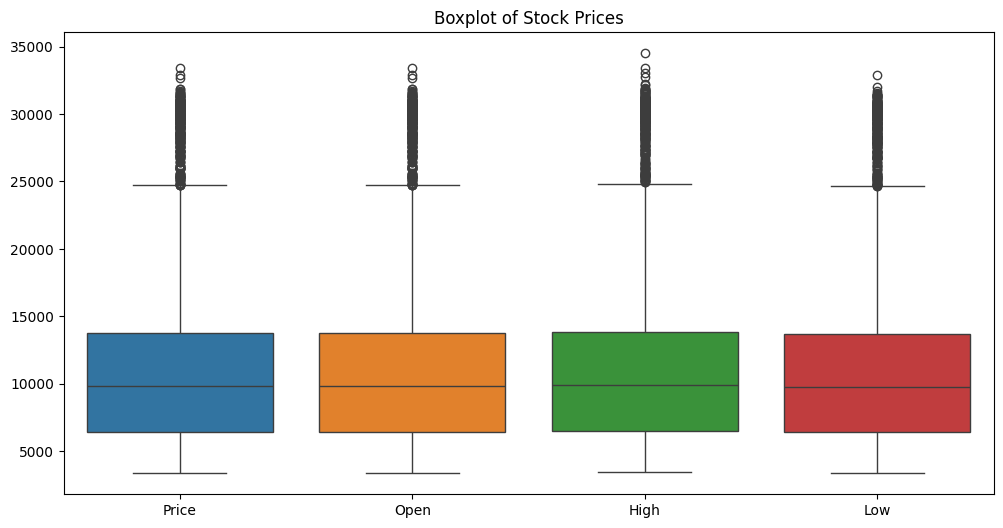

,Date,Price,Open,High,Low,Vol.,Change %
0,2025-02-06,30011.84,29735.59,30011.84,29735.59,83500000.0,0.93
1,2025-02-05,29735.59,29668.47,29772.63,29596.50,103710000.0,0.23
2,2025-02-04,29668.47,29754.77,29937.39,29668.47,135050000.0,-0.29
3,2025-02-03,29754.77,29917.96,30001.23,29698.79,152060000.0,-0.55
4,2025-02-02,29917.96,30010.62,30198.22,29917.96,103160000.0,-0.31
5,2025-01-30,30010.62,29891.61,30127.35,29891.61,127580000.0,0.40
6,2025-01-29,29891.61,29646.60,29982.32,29646.60,112710000.0,0.83
7,2025-01-28,29646.60,29742.12,29900.15,29646.60,63280000.0,-0.32
8,2025-01-27,29742.12,30034.85,30091.04,29726.66,90870000.0,-0.97
9,2025-01-26,30034.85,29997.69,30276.52,29995.30,76040000.0,0.12


In [644]:
# Plot boxplots to detect outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[["Price", "Open", "High", "Low"]])
plt.title("Boxplot of Stock Prices")
plt.show()

# Check for statistical outliers using IQR
Q1 = df[["Price", "Open", "High", "Low"]].quantile(0.25)
Q3 = df[["Price", "Open", "High", "Low"]].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[["Price", "Open", "High", "Low"]] < (Q1 - 1.5 * IQR)) | 
            (df[["Price", "Open", "High", "Low"]] > (Q3 + 1.5 * IQR))).sum()

outliers

outlier_condition = (df[["Price", "Open", "High", "Low"]] < (Q1 - 1.5 * IQR)) | (df[["Price", "Open", "High", "Low"]] > (Q3 + 1.5 * IQR))
outliers_df = df[outlier_condition.any(axis=1)]

# Display the first few rows of detected outliers
outliers_df.head(10)

During **2023 and 2024** , Egypt experienced significant economic events and policy changes that likely influenced stock prices:

**Economic Events**

- Inflation Surge: Annual inflation rates reached a peak of 38% in September 2023, before easing to 24% in January 2025.
  ([TRADINGECONOMICS.COM](https://tradingeconomics.com/egypt/inflation-cpi))

- GDP Growth Decline: The real GDP growth rate slowed to 2.4% in the fourth quarter of the fiscal year 2023/2024, down from 3.8% the previous year.
  ([MPED.GOV.EG](https://mped.gov.eg/singlenews?id=5718&lang=en&utm_source=chatgpt.com))

**Government Policies**

- Minimum Wage Increase: In February 2025, the government announced a raise in the monthly minimum wage for public sector workers to 7,000 Egyptian pounds, effective July 2025.
  ([REUTERS.COM](https://www.reuters.com/world/africa/egypt-raise-monthly-minimum-wages-public-sector-workers-2025-02-26/?utm_source=chatgpt.com))

- Social Protection Initiatives: An 80-85 billion Egyptian pounds social protection package was introduced, including increased support for the ration card system, benefiting 10 million vulnerable families.
  ([REUTERS.COM](https://www.reuters.com/world/africa/egypt-raise-monthly-minimum-wages-public-sector-workers-2025-02-26/?utm_source=chatgpt.com))


# Exploratory Data Analysis (EDA)


## INFO

In [645]:
print(df.describe())

                                Date         Price          Open  \
count                           3906   3906.000000   3906.000000   
mean   2017-01-13 01:01:11.889400832  11158.756915  11154.666736   
min              2008-11-27 00:00:00   3389.310000   3389.310000   
25%              2013-01-14 06:00:00   6457.602500   6456.152500   
50%              2017-01-11 12:00:00   9860.015000   9865.140000   
75%              2021-02-01 18:00:00  13776.070000  13770.892500   
max              2025-02-06 00:00:00  33382.510000  33382.510000   
std                              NaN   6388.627323   6381.427839   

               High           Low          Vol.     Change %  
count   3906.000000   3906.000000  3.906000e+03  3906.000000  
mean   11242.017386  11082.929224  1.432738e+08     0.066370  
min     3484.100000   3380.330000  9.310000e+06   -10.520000  
25%     6494.240000   6422.047500  7.400250e+07    -0.680000  
50%     9925.195000   9789.980000  1.155350e+08     0.090000  
75%    13

- Price, Open, High, Low Similarities:
  The mean values for Price, Open, High, and Low are very close, and their quartiles are almost identical. This implies that on most days, the opening, closing, and extreme prices (high and low) do not differ dramatically. In other words, the intraday price fluctuation tends to be small compared to the overall price level.


## Trend Analysis


In [646]:
# import pandas as pd
# from datetime import timedelta
# from dateutil.relativedelta import relativedelta    
# # Stock Price Trend Over Time
# plt.figure(figsize=(14, 6))
# plt.plot(df["Date"], df["Price"], label="Closing Price", color="blue")
# plt.title("Stock Price Trend Over Time")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend()
# plt.show()

# # Seasonal Decomposition
# decompose_result = seasonal_decompose(df["Price"], model='additive', period=252)
# decompose_result.plot()
# plt.suptitle("Seasonal Decomposition (Daily Data, period=252)", fontsize=14)
# plt.tight_layout()
# plt.show()

# # Decompose the weekly time series
# df_weekly = df.resample("W", on="Date").mean().reset_index()
# df_weekly_for_decomp = df_weekly.copy()
# df_weekly_for_decomp.index = pd.DatetimeIndex(df_weekly_for_decomp["Date"])


# result_weekly = seasonal_decompose(df_weekly_for_decomp["Price"], model='additive', period=52)
# result_weekly.plot()
# plt.suptitle("Seasonal Decomposition (Weekly Data, period=52)", fontsize=14)
# plt.tight_layout()
# plt.show()

# # Decompose the monthly time series
# df_monthly = df.resample("M", on="Date").mean().reset_index()
# df_monthly_for_decomp = df_monthly.copy()
# df_monthly_for_decomp.index = pd.DatetimeIndex(df_monthly_for_decomp["Date"])
# df_monthly_for_decomp["Price"] = df_monthly_for_decomp["Price"].ffill()
# result_monthly = seasonal_decompose(df_monthly_for_decomp["Price"], model='additive', period=12)
# result_monthly.plot()
# plt.suptitle("Seasonal Decomposition (Monthly Data, period=12)", fontsize=14)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(14, 6))
# plt.plot(df["Date"], df["Price"], label="Closing Price", color="blue")
# plt.scatter(outliers_df["Date"], outliers_df["Price"], color="red", label="Outliers")
# plt.xlabel("Date")
# plt.ylabel("Stock Price")
# plt.title("Stock Price Trend with Outliers Highlighted")
# plt.legend()
# plt.show()


## Correlation analysis


Correlation Matrix:
             Price      Open      High       Low      Vol.  Change %
Price     1.000000  0.999584  0.999791  0.999822  0.324710  0.021563
Open      0.999584  1.000000  0.999832  0.999763  0.322699 -0.000454
High      0.999791  0.999832  1.000000  0.999714  0.325433  0.009742
Low       0.999822  0.999763  0.999714  1.000000  0.322570  0.011856
Vol.      0.324710  0.322699  0.325433  0.322570  1.000000  0.118769
Change %  0.021563 -0.000454  0.009742  0.011856  0.118769  1.000000


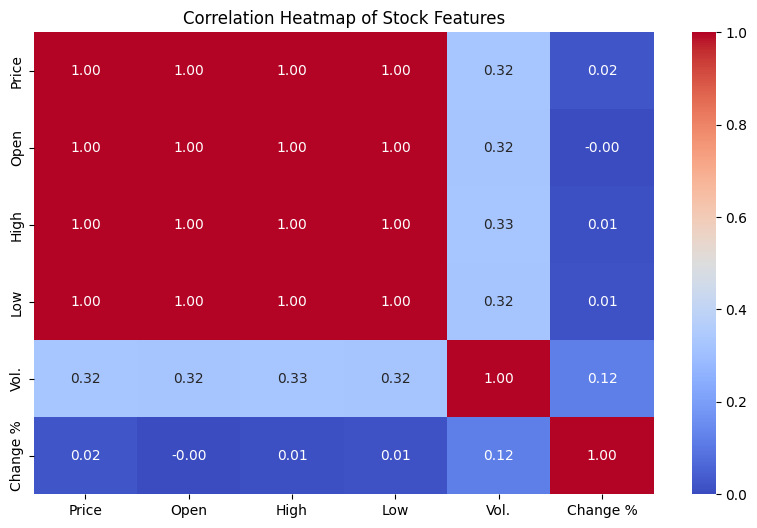

In [647]:
numerical_features= df.select_dtypes(include=['float64']).copy()
corr_matrix = numerical_features.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Stock Features")
plt.show()

## Feature Engineering


### Moving Averages


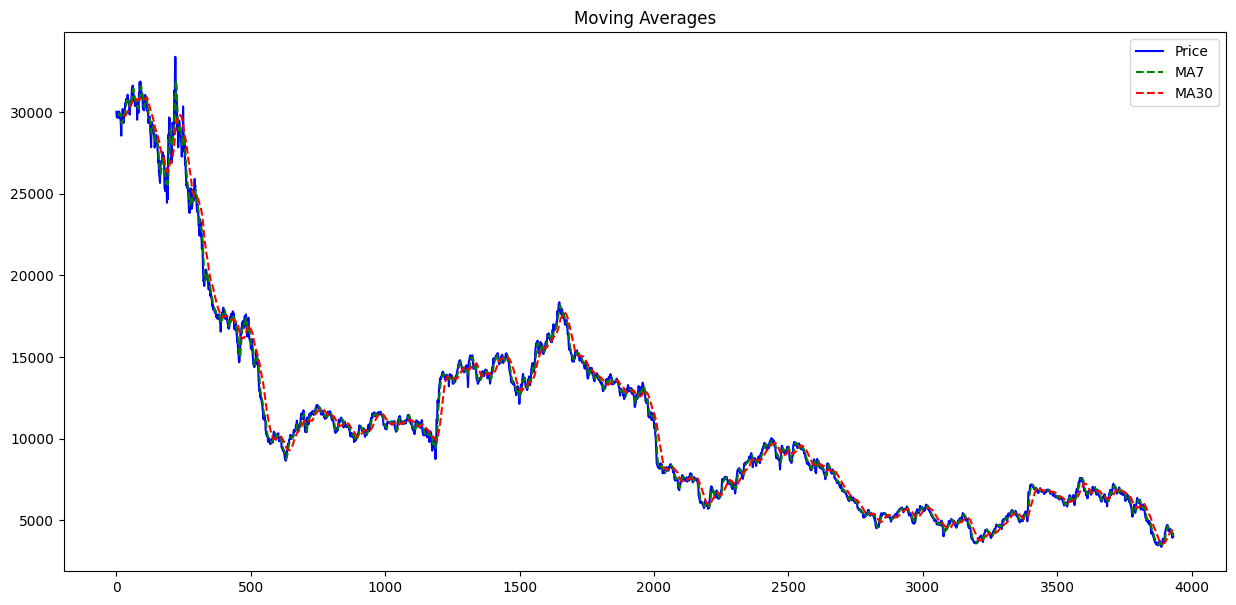

In [648]:
df['MA7'] = df['Price'].rolling(window=7).mean()
df['MA30'] = df['Price'].rolling(window=30).mean()

plt.figure(figsize=(15,7))
plt.plot(df['Price'], label='Price', color='blue')
plt.plot(df['MA7'], label='MA7', linestyle='dashed', color='green')
plt.plot(df['MA30'], label='MA30', linestyle='dashed', color='red')
plt.legend()
plt.title('Moving Averages')
plt.show()

**MA7** (7-day) (green line) tracks the Price closely, reacting more quickly to short-term fluctuations. You can see that it moves almost in sync with the Price, but with slightly smoother peaks and troughs.

**MA30** (30-day) (red, dashed line) is smoother and lags behind the immediate price changes. It captures a more medium-term trend, filtering out much of the short-term volatility.


Given the overall decline in Price, both MAs confirm a sustained downward movement, though the 7-day MA shows smaller wiggles along the way.

This can be indicative of a prolonged bear market in the period captured by the data, with short rallies that don’t significantly alter the longer downward trend.


### Daily Return


In [649]:
df["Daily Return"] = df["Price"].pct_change()
df["Daily Range"] = df["High"] - df["Low"]
df["Price Change"] = df["Price"] - df["Open"]

### Rolling Volatility


<Figure size 1400x1000 with 0 Axes>

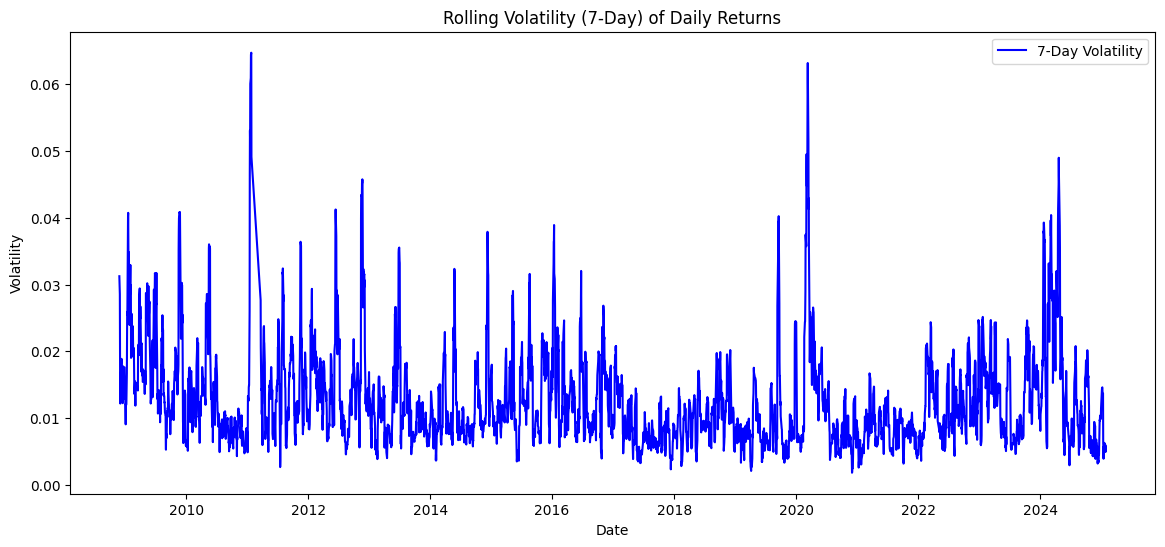

In [650]:
df["Volatility"] = df["Daily Return"].rolling(window=7).std()

plt.figure(figsize=(14, 10))
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Volatility"], label="7-Day Volatility", color="blue")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("Rolling Volatility (7-Day) of Daily Returns")
plt.legend()
plt.show()

**Spiky Periods**:

- The chart shows multiple volatility spikes—some reaching above 0.04–0.06 (or 4–6% in daily return standard deviation).
- These spikes could be linked to major news events, economic crises, currency devaluations, or political changes that caused rapid price swings.

**Quiet Periods**:

- Between spikes, volatility often settles below 0.01–0.02.
- Low volatility suggests more stable or less reactive market conditions over those weeks.


### Relative Strength Index (RSI)


In [651]:
df = df.sort_values('Date', ascending=True)

In [652]:
import pandas as pd
from datetime import timedelta
from dateutil.relativedelta import relativedelta
def filter_by_custom_date(df, date_column='Date', type_date='month', number_of_date_type=1):
    # Ensure date column is datetime
    df[date_column] = pd.to_datetime(df[date_column])

    # Use the last available date in the dataset
    last_date = df[date_column].max()

    if type_date == 'day':
        start_date = last_date - timedelta(days=number_of_date_type)
    elif type_date == 'month':
        start_date = last_date - relativedelta(months=number_of_date_type)
    elif type_date == 'year':
        start_date = last_date - relativedelta(years=number_of_date_type)
    else:
        raise ValueError("Invalid 'type_date'. Choose from 'day', 'month', or 'year'.")

    # Filter the DataFrame
    filtered_df = df[df[date_column] >= start_date]

    return filtered_df


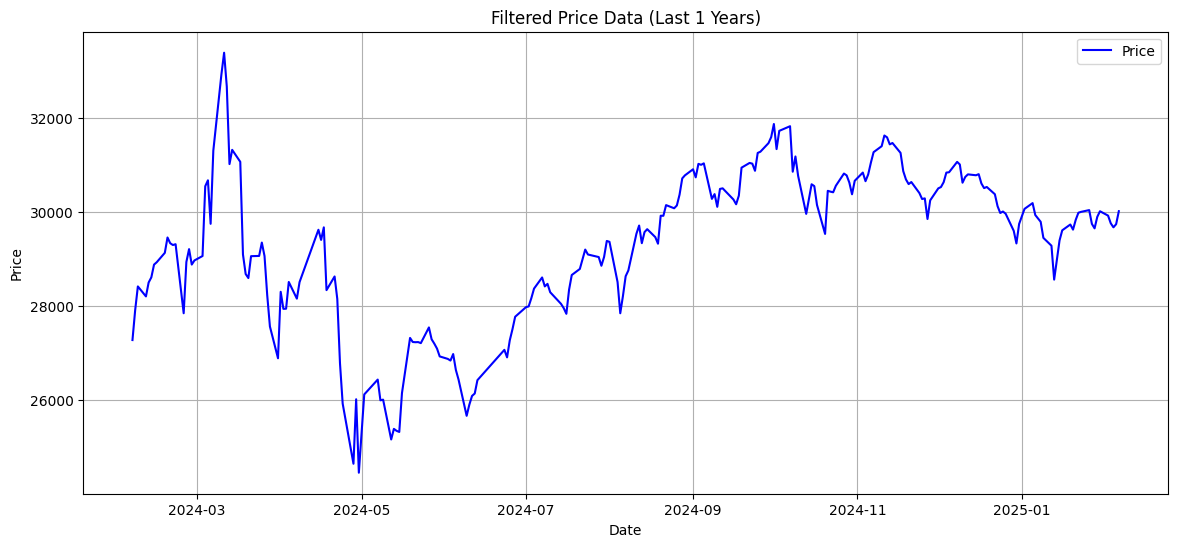

In [653]:


# Assuming your DataFrame is named `data` and it has a 'Date' column
# Filter last 2 years of data
filtered_years = filter_by_custom_date(df, type_date='year', number_of_date_type=1)
# Filter last 7 years of data
filtered_7_years= filter_by_custom_date(df, type_date='year', number_of_date_type=7)
# Filter last 1 months of data
filtered_months =  filter_by_custom_date(df, type_date='month', number_of_date_type=1)
# Filter last 6 months of data
filtered_6_months =  filter_by_custom_date(df, type_date='month', number_of_date_type=6)
# Filter last 14 days
filtered_days =  filter_by_custom_date(df, type_date='day', number_of_date_type=14)

# print(filtered_years)
filtered_years = filtered_years.sort_values('Date', ascending=True)
filtered_years

# df = filtered_years


# Now you can work with filtered_data_30_days and plot or analyze it
# Plot the filtered data
plt.figure(figsize=(14, 6))
plt.plot(filtered_years["Date"], filtered_years["Price"], label="Price", color="blue")
plt.title("Filtered Price Data (Last 1 Years)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [654]:
df[["Date"]].describe()

,Date
count,3906
mean,2017-01-13 01:01:11.889400832
min,2008-11-27 00:00:00
25%,2013-01-14 06:00:00
50%,2017-01-11 12:00:00
75%,2021-02-01 18:00:00
max,2025-02-06 00:00:00


        Date     Price        RSI
4 2025-02-02  29917.96  51.061581
3 2025-02-03  29754.77  47.885025
2 2025-02-04  29668.47  46.246537
1 2025-02-05  29735.59  47.744166
0 2025-02-06  30011.84  53.487952
Missing Values:
 Date            0
Price           0
Open            0
High            0
Low             0
Vol.            0
Change %        0
MA7             0
MA30            0
Daily Return    0
Daily Range     0
Price Change    0
Volatility      0
RSI             0
dtype: int64


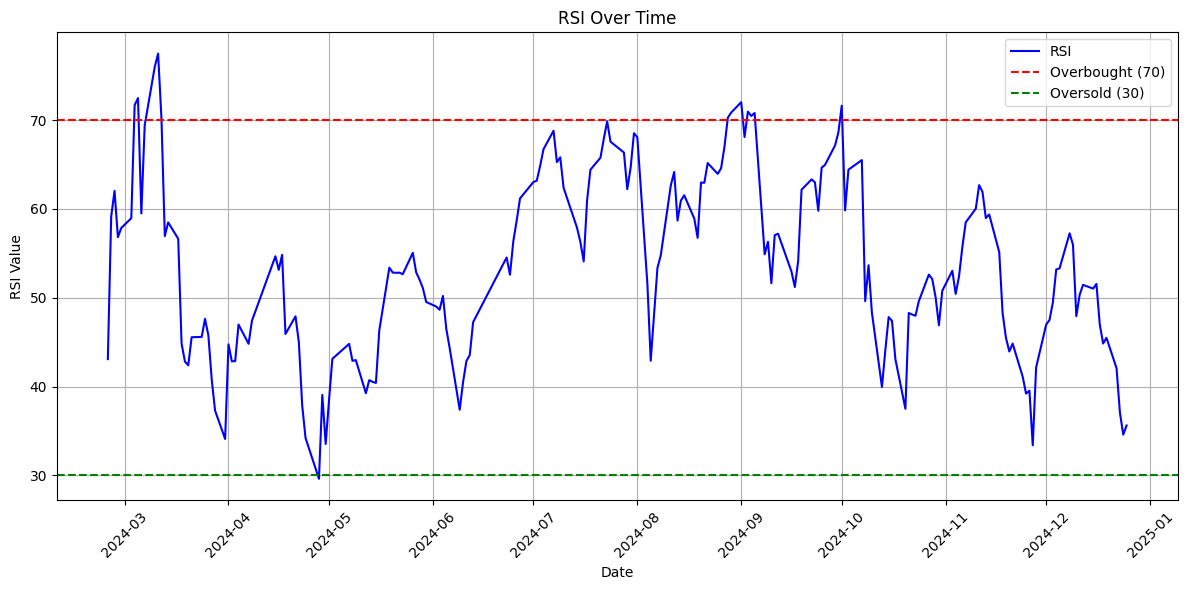

In [655]:
from io import StringIO

filtered_years['Date'] = pd.to_datetime(filtered_years['Date'])

df['RSI'] = ta.momentum.rsi(filtered_years['Price'], window=14)

print(df[['Date', 'Price', 'RSI']].tail())

df.dropna(inplace=True)

print("Missing Values:\n", df.isnull().sum())

# plt.figure(figsize=(12, 6))
# plt.plot(df['Date'], df['RSI'], label='RSI', color='blue')
# plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
# plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')
# plt.title('RSI Over Time')
# plt.xlabel('Date')
# plt.ylabel('RSI Value')
# plt.legend()
# plt.grid(True)
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# احذف plt.ylim(0, 100) علشان ما تثبتش الحدود

# باقي الكود
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['RSI'], label='RSI', color='blue')

plt.axhline(70, color='red', linestyle='--', label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', label='Oversold (30)')

plt.title('RSI Over Time')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Above 70–80** (red line ) often suggests overbought conditions.

**Below 20–30** (green line) often suggests oversold conditions.


The RSI is highly active, indicating frequent shifts in momentum.

Overbought and oversold zones are reached regularly, suggesting either a short calculation period or a very volatile market.


### Moving Average Convergence Divergence (MACD)


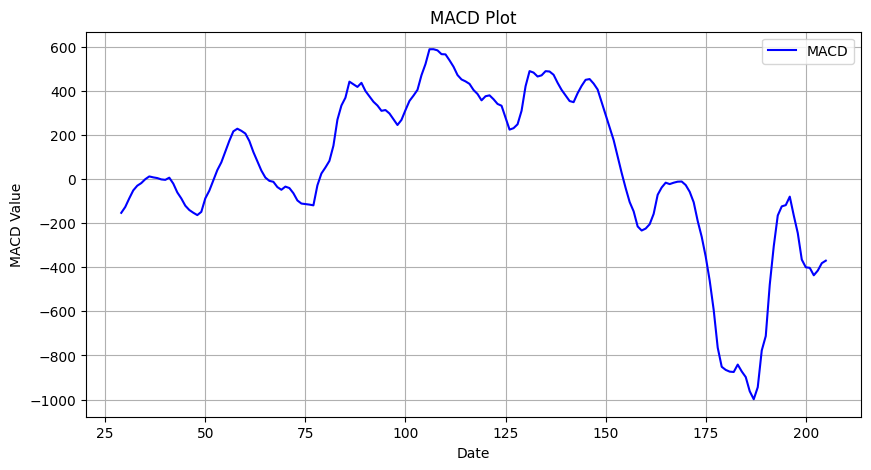

In [656]:
df["MACD"] = ta.trend.MACD(df["Price"]).macd()
# Plotting the MACD
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["MACD"], label='MACD', color='b')
plt.title('MACD Plot')
plt.xlabel('Date')
plt.ylabel('MACD Value')
plt.legend()
plt.grid(True)
plt.show()

In [657]:
df["Signal Line"] = df["MACD"].ewm(span=9, adjust=False).mean()

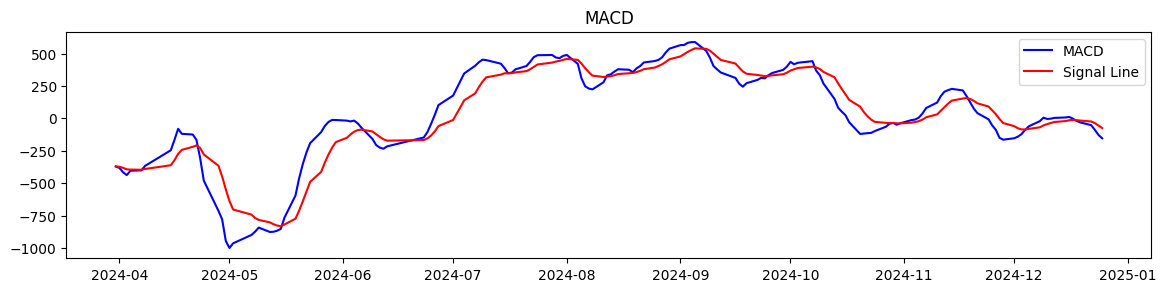

In [658]:
plt.figure(figsize=(14, 10))
plt.subplot(3, 1, 2)
plt.plot(df["Date"], df["MACD"], label="MACD", color="blue")
plt.plot(df["Date"], df["Signal Line"], label="Signal Line", color="red")
plt.title("MACD")
plt.legend()

**Frequent Crossovers**

- The blue and red lines cross multiple times, suggesting frequent momentum changes.
- Each crossover can be interpreted as a shift in short-term vs. long-term momentum.

**Large Swings**

- Notable spikes occur around 2016, 2020, and 2024, with the MACD moving above or below ±500–1000.
- These spikes indicate strong bullish or bearish momentum, likely tied to major price moves or market events.

**Periods Near Zero**

- There are intervals where MACD and the Signal Line hover near zero, suggesting relatively balanced momentum or a sideways market.


### Bollinger Bands


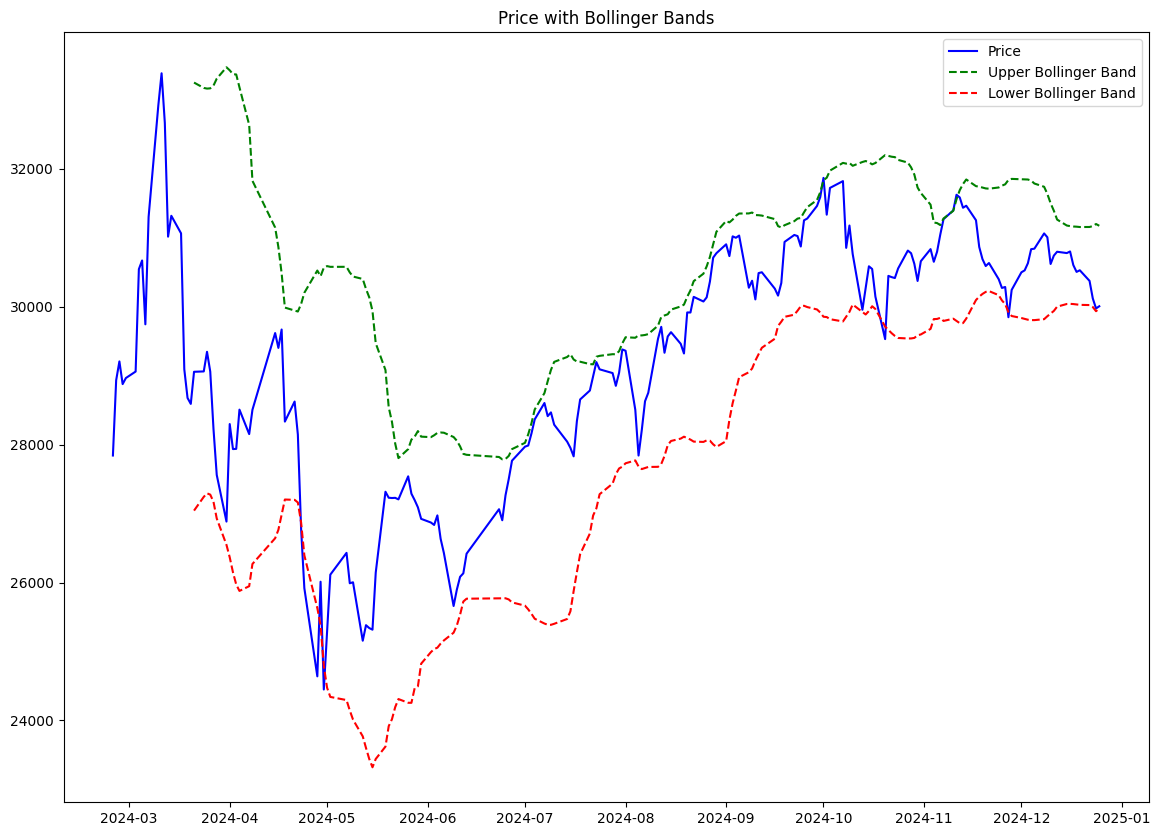

In [659]:
bb = ta.volatility.BollingerBands(df["Price"], window=20)
df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()

plt.figure(figsize=(14, 10))
plt.plot(df["Date"], df["Price"], label="Price", color="blue")
plt.plot(df["Date"], df["BB_High"], label="Upper Bollinger Band", linestyle="--", color="green")
plt.plot(df["Date"], df["BB_Low"], label="Lower Bollinger Band", linestyle="--", color="red")
plt.title("Price with Bollinger Bands")
plt.legend()

Upper Band (green, dotted) and Lower Band (red, dotted) typically lie ±2 standard deviations from a 20-day moving average (the middle band).

They expand when volatility (standard deviation) increases and contract when volatility decreases.


**Long-Term Uptrend**
The chart shows a steady rise from below 5,000 in early years (2008–2010) to over 30,000 by 2024–2025.
Notably, there’s an accelerated climb from around 2020 onward.

**Periods of High Volatility**
When the price surges sharply (e.g., 2020–2025), the bands widen significantly, reflecting larger price swings.
Around major price peaks, the upper band is far above the middle band, indicating increased volatility.

**Band Touches and Mean Reversion**
During strong uptrends, the price can stay near the upper band for extended periods, suggesting bullish momentum.
When price touches or crosses below the lower band, it may signal oversold conditions or a downward correction.


**The chart confirms a strong long-term uptrend with phases of high volatility, especially post-2020.**


### Quarter of the Year


C:\Users\ziadh\AppData\Local\Temp\ipykernel_19660\3884418148.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarter_counts.index, y=quarter_counts.values, palette="Paired")


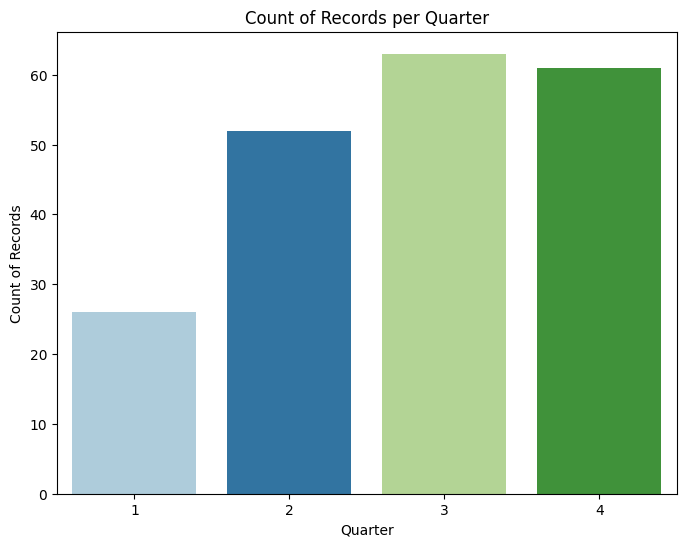

In [660]:
df["Quarter"] = df["Date"].dt.quarter

plt.figure(figsize=(8, 6))
quarter_counts = df["Quarter"].value_counts().sort_index()
sns.barplot(x=quarter_counts.index, y=quarter_counts.values, palette="Paired")
plt.xlabel("Quarter")
plt.ylabel("Count of Records")
plt.title("Count of Records per Quarter")
plt.show()

Each quarter has roughly 900–1000 records, indicating the dataset is fairly balanced across Q1, Q2, Q3, and Q4.

The dataset may include partial-year data that skews toward Q4.


C:\Users\ziadh\AppData\Local\Temp\ipykernel_19660\3761644068.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Quarter", y="Price", data=df, palette="Paired")


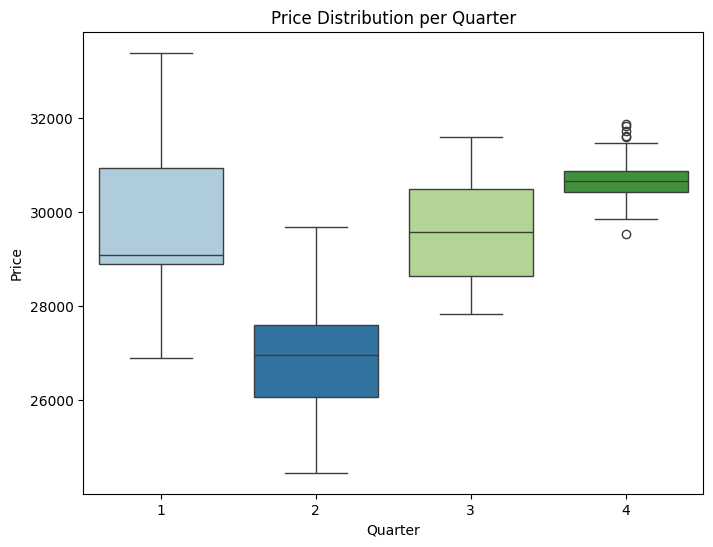

In [661]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Quarter", y="Price", data=df, palette="Paired")
plt.xlabel("Quarter")
plt.ylabel("Price")
plt.title("Price Distribution per Quarter")
plt.show()

Q2 shows a lower median price, raising questions about potential seasonal dips or partial data coverage.

The presence of outliers in all quarters indicates significant price spikes at various times, not confined to any single quarter.


### Average True Range (ATR)


In [662]:
df["Previous_Close"] = df["Price"].shift(1)

df["High_Low"] = df["High"] - df["Low"]
df["High_PC"] = (df["High"] - df["Previous_Close"]).abs()  
df["Low_PC"] = (df["Low"] - df["Previous_Close"]).abs()    

df["TR"] = df[["High_Low", "High_PC", "Low_PC"]].max(axis=1)

window = 14
df["ATR"] = df["TR"].rolling(window=window, min_periods=window).mean()

print(df[["Date", "Price", "High", "Low", "Previous_Close", "TR", "ATR"]].tail(20))

         Date     Price      High       Low  Previous_Close      TR  \
48 2024-11-28  30242.13  30242.13  29763.65        29846.04  478.48   
47 2024-12-01  30497.13  30502.15  30242.13        30242.13  260.02   
46 2024-12-02  30525.32  30675.44  30429.45        30497.13  245.99   
45 2024-12-03  30628.74  30642.46  30525.32        30525.32  117.14   
44 2024-12-04  30832.61  31005.17  30628.74        30628.74  376.43   
43 2024-12-05  30839.57  31035.14  30824.25        30832.61  210.89   
42 2024-12-08  31060.51  31232.73  30839.57        30839.57  393.16   
41 2024-12-09  31005.12  31185.24  30977.11        31060.51  208.13   
40 2024-12-10  30617.83  31067.10  30617.83        31005.12  449.27   
39 2024-12-11  30739.26  30807.78  30581.63        30617.83  226.15   
38 2024-12-12  30795.09  30879.01  30739.26        30739.26  139.75   
37 2024-12-15  30776.00  30835.57  30621.08        30795.09  214.49   
36 2024-12-16  30799.43  30918.19  30682.68        30776.00  235.51   
35 202

**High_Low**: The difference between the current day’s high and low.

**High_PC**: The absolute difference between the current day’s high and the previous day’s close.

**Low_PC**: The absolute difference between the current day’s low and the previous day’s close.

**The TR** is then the maximum of these three values for each day.


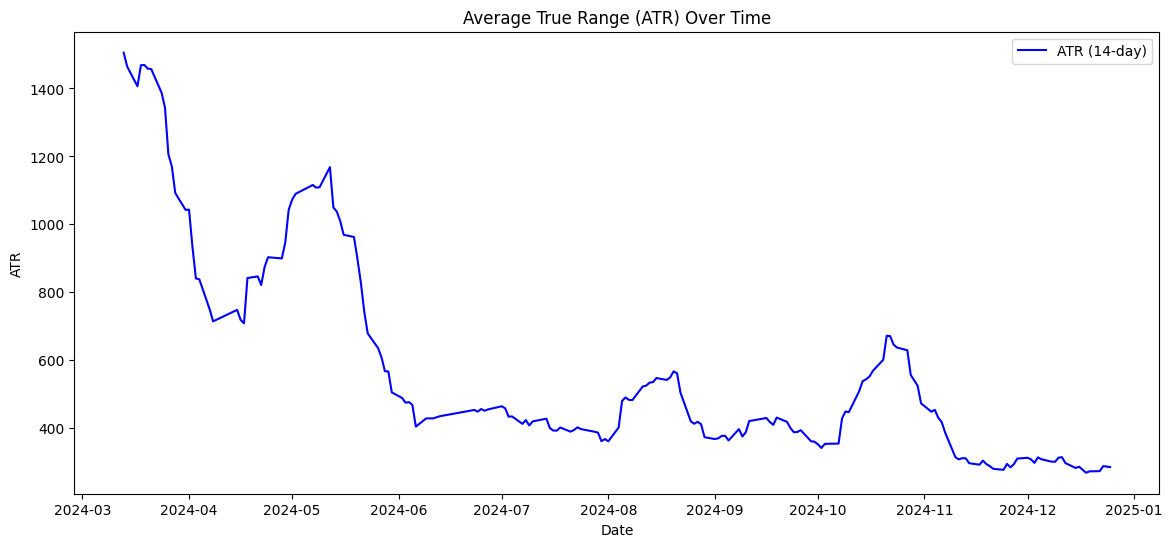

In [663]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["ATR"], label="ATR (14-day)", color="blue")
plt.xlabel("Date")
plt.ylabel("ATR")
plt.title("Average True Range (ATR) Over Time")
plt.legend()
plt.show()

**Relatively Low ATR (2008–2020)**
From 2008 through much of the early 2010s, the ATR remains below 200–300, indicating relatively lower volatility compared to later years.

**Significant Increase (2020–2025)**
Post-2020, the ATR shows sizable and frequent spikes, with peaks surpassing 500–1000, and at one point reaching around 2000.


Long-Term Perspective: The market was relatively less volatile before 2020, with dramatic volatility spikes in the 2023–2024 period.


### Stochastic Oscillator


In [664]:
k_period = 14  # Look-back period for %K
d_period = 3   # Moving average period for %D

df['Lowest_Low'] = df['Low'].rolling(window=k_period).min()
df['Highest_High'] = df['High'].rolling(window=k_period).max()

df['%K'] = 100 * ((df['Price'] - df['Lowest_Low']) / (df['Highest_High'] - df['Lowest_Low']))

df['%D'] = df['%K'].rolling(window=d_period).mean()

print(df[["Date", "Price", "Lowest_Low", "Highest_High", "%K", "%D"]].tail(10))

         Date     Price  Lowest_Low  Highest_High         %K         %D
38 2024-12-12  30795.09    29763.65      31232.73  70.209927  64.921130
37 2024-12-15  30776.00    29763.65      31232.73  68.910475  68.509997
36 2024-12-16  30799.43    29763.65      31232.73  70.505350  69.875251
35 2024-12-17  30601.64    29763.65      31232.73  57.041822  65.485882
34 2024-12-18  30503.07    30242.13      31232.73  26.341611  51.296261
33 2024-12-19  30526.71    30211.82      31232.73  30.844051  38.075828
32 2024-12-22  30372.70    30211.82      31232.73  15.758490  24.314717
31 2024-12-23  30118.38    30118.38      31232.73   0.000000  15.534180
30 2024-12-24  29973.15    29810.40      31232.73  11.442492   9.066994
29 2024-12-25  30005.00    29810.40      31232.73  13.681776   8.374756


stoch_%K    15
stoch_%D    17
Date         0
dtype: int64


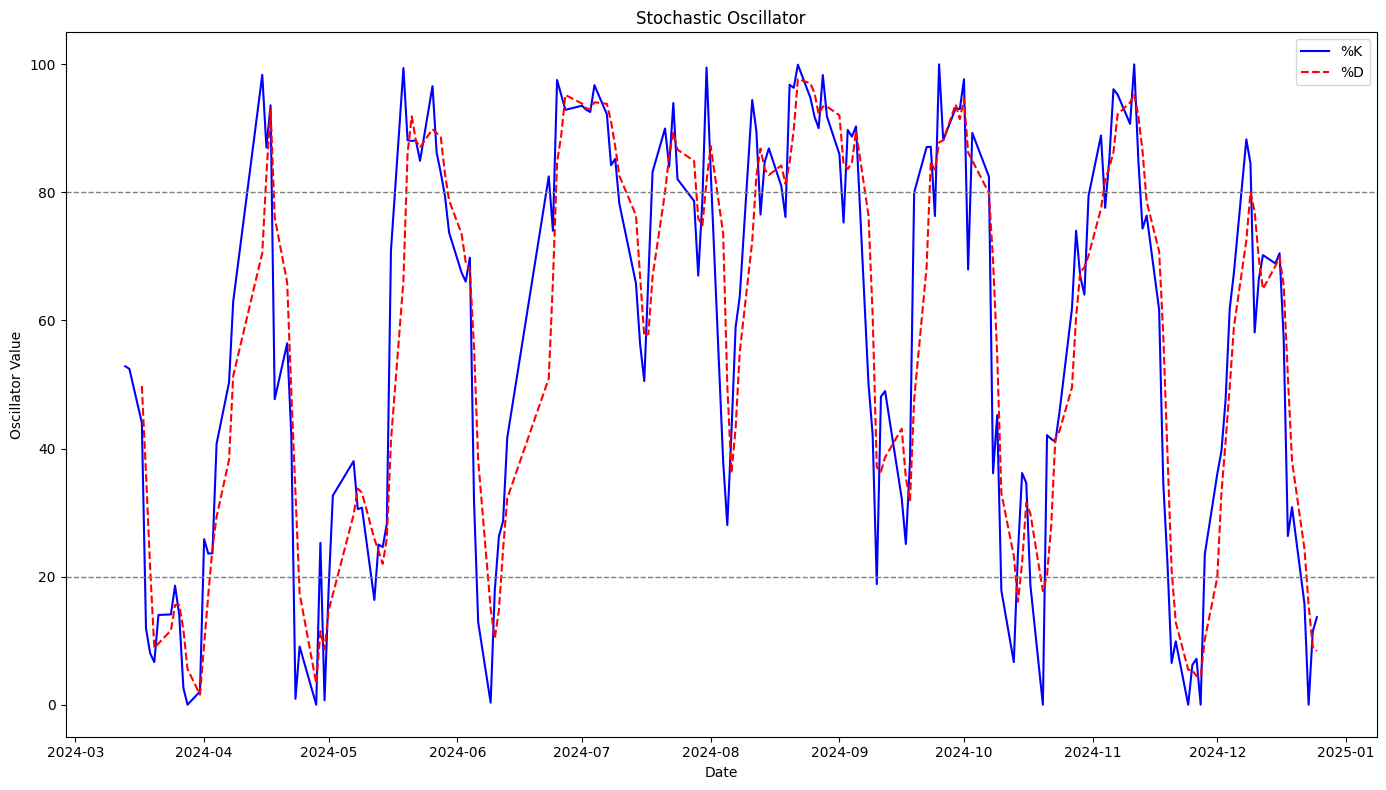

In [665]:
# The presence of outliers in all quarters indicates significant price spikes at various times, not confined to any single quarter.

def stochastic_slow(df, k_period=14, d_period=3, showing=3):
    # Fast %K
    low_min = df['Low'].rolling(window=k_period).min()
    high_max = df['High'].rolling(window=k_period).max()
    fast_k = 100 * ((df['Price'] - low_min) / (high_max - low_min))

    # Slow %K (3-period SMA of Fast %K)
    slow_k = fast_k.rolling(window=d_period).mean()

    # Slow %D (3-period SMA of Slow %K)
    slow_d = slow_k.rolling(window=d_period).mean()

    # Add to the original dataframe
    df['stoch_%K'] = slow_k
    df['stoch_%D'] = slow_d

    return df

# Load your OHLC data into df (DataFrame with 'High', 'Low', 'Close')
result = stochastic_slow(df, k_period=14, d_period=3, showing=3)
print(result[['stoch_%K','stoch_%D','Date']].isnull().sum())

plt.figure(figsize=(14, 8))


plt.plot(result["Date"], result["%K"], label="%K", color="blue")
plt.plot(result["Date"], result["%D"], label="%D", color="red", linestyle="--")


plt.axhline(80, color="gray", linestyle="--", linewidth=1)
plt.axhline(20, color="gray", linestyle="--", linewidth=1)

plt.title("Stochastic Oscillator")
plt.xlabel("Date")
plt.ylabel("Oscillator Value")
plt.legend()
plt.tight_layout()
plt.show()


Above 80 typically indicating overbought conditions.
Below 20 typically indicating oversold conditions.


**Frequent Spikes**

The oscillator oscillates rapidly between 0 and 100, suggesting either a very short lookback period (like 14 days for %K) or a highly volatile market—or both.

The lines (%K and %D) crisscross frequently, generating many potential overbought/oversold signals.

**No Extended Flat Regions**

The plot shows the oscillator rarely stays pinned at the top or bottom for long. Instead, it quickly reverts, indicating constant shifts in momentum.

**Volatile Environment**

When prices are volatile or the time period for the Stochastic calculation is short, the oscillator can produce frequent whipsaws, requiring additional confirmation from other indicators or higher smoothing.


**The Stochastic Oscillator is highly active**


### ROC

In [666]:
# def apply_roc_strategy(df, period=12):
#     # Calculate ROC (Rate of Change)
#     df['ROC'] = ((df['Price'] - df['Price'].shift(period)) / df['Price'].shift(period)) * 100

#     # Signal logic
#     def roc_decision(row, prev_row):
#         if np.isnan(row['ROC']) or np.isnan(prev_row['ROC']):
#             return 0
        
#         # ROC crossing above zero
#         if prev_row['ROC'] < 0 and row['ROC'] > 0:
#             return 1  # BUY
#         # ROC crossing below zero
#         elif prev_row['ROC'] > 0 and row['ROC'] < 0:
#             return -1  # SELL
#         else:
#             return 0  # NEUTRAL

#     # Apply the decision logic
#     decisions = [0]
#     for i in range(1, len(df)):
#         decisions.append(roc_decision(df.iloc[i], df.iloc[i - 1]))

#     df['ROC_decision'] = decisions

#     return df
# df = apply_roc_strategy(df, period=12)
# print(df[['Price', 'ROC', 'ROC_decision']].tail())
# print(df[['ROC_decision']].value_counts())

def apply_roc_strategy(df, period=12, threshold=2.0):
    # Calculate ROC
    df['ROC'] = ((df['Price'] - df['Price'].shift(period)) / df['Price'].shift(period)) * 100

    # Decision logic with threshold
    def roc_decision(row, prev_row):
        if np.isnan(row['ROC']) or np.isnan(prev_row['ROC']):
            return 0

        # Buy signal: crossing threshold from below
        if prev_row['ROC'] < threshold and row['ROC'] >= threshold:
            return 1
        # Sell signal: crossing -threshold from above
        elif prev_row['ROC'] > -threshold and row['ROC'] <= -threshold:
            return -1
        else:
            return 0

    # Apply logic
    decisions = [0]
    for i in range(1, len(df)):
        decisions.append(roc_decision(df.iloc[i], df.iloc[i - 1]))
    
    df['ROC_decision'] = decisions
    return df
df = apply_roc_strategy(df, period=12)
print(df[['Price', 'ROC', 'ROC_decision']].tail())
print(df[['ROC_decision']].value_counts())

       Price       ROC  ROC_decision
33  30526.71 -0.333119             0
32  30372.70 -1.491635             0
31  30118.38 -2.338522            -1
30  29973.15 -3.500780             0
29  30005.00 -3.225661             0
ROC_decision
 0              181
 1               15
-1                6
Name: count, dtype: int64


### Correlation analysis


Correlation Matrix:
                   Price      Open      High       Low      Vol.  Change %  \
Price           1.000000  0.959015  0.977339  0.984287 -0.310988  0.139801   
Open            0.959015  1.000000  0.983319  0.975147 -0.304390 -0.145616   
High            0.977339  0.983319  1.000000  0.970486 -0.228235 -0.022487   
Low             0.984287  0.975147  0.970486  1.000000 -0.360675  0.026377   
Vol.           -0.310988 -0.304390 -0.228235 -0.360675  1.000000 -0.022658   
Change %        0.139801 -0.145616 -0.022487  0.026377 -0.022658  1.000000   
MA7             0.922097  0.880471  0.897676  0.911350 -0.352230  0.139977   
MA30            0.774960  0.749566  0.730244  0.793198 -0.460575  0.081713   
Daily Return    0.140272  0.139910  0.130035  0.147068  0.001028  0.011607   
Daily Range    -0.175650 -0.113873 -0.027918 -0.268156  0.583267 -0.199167   
Price Change    0.144545 -0.141758 -0.019492  0.033319 -0.023483  0.996900   
Volatility     -0.202016 -0.171091 -0.109181

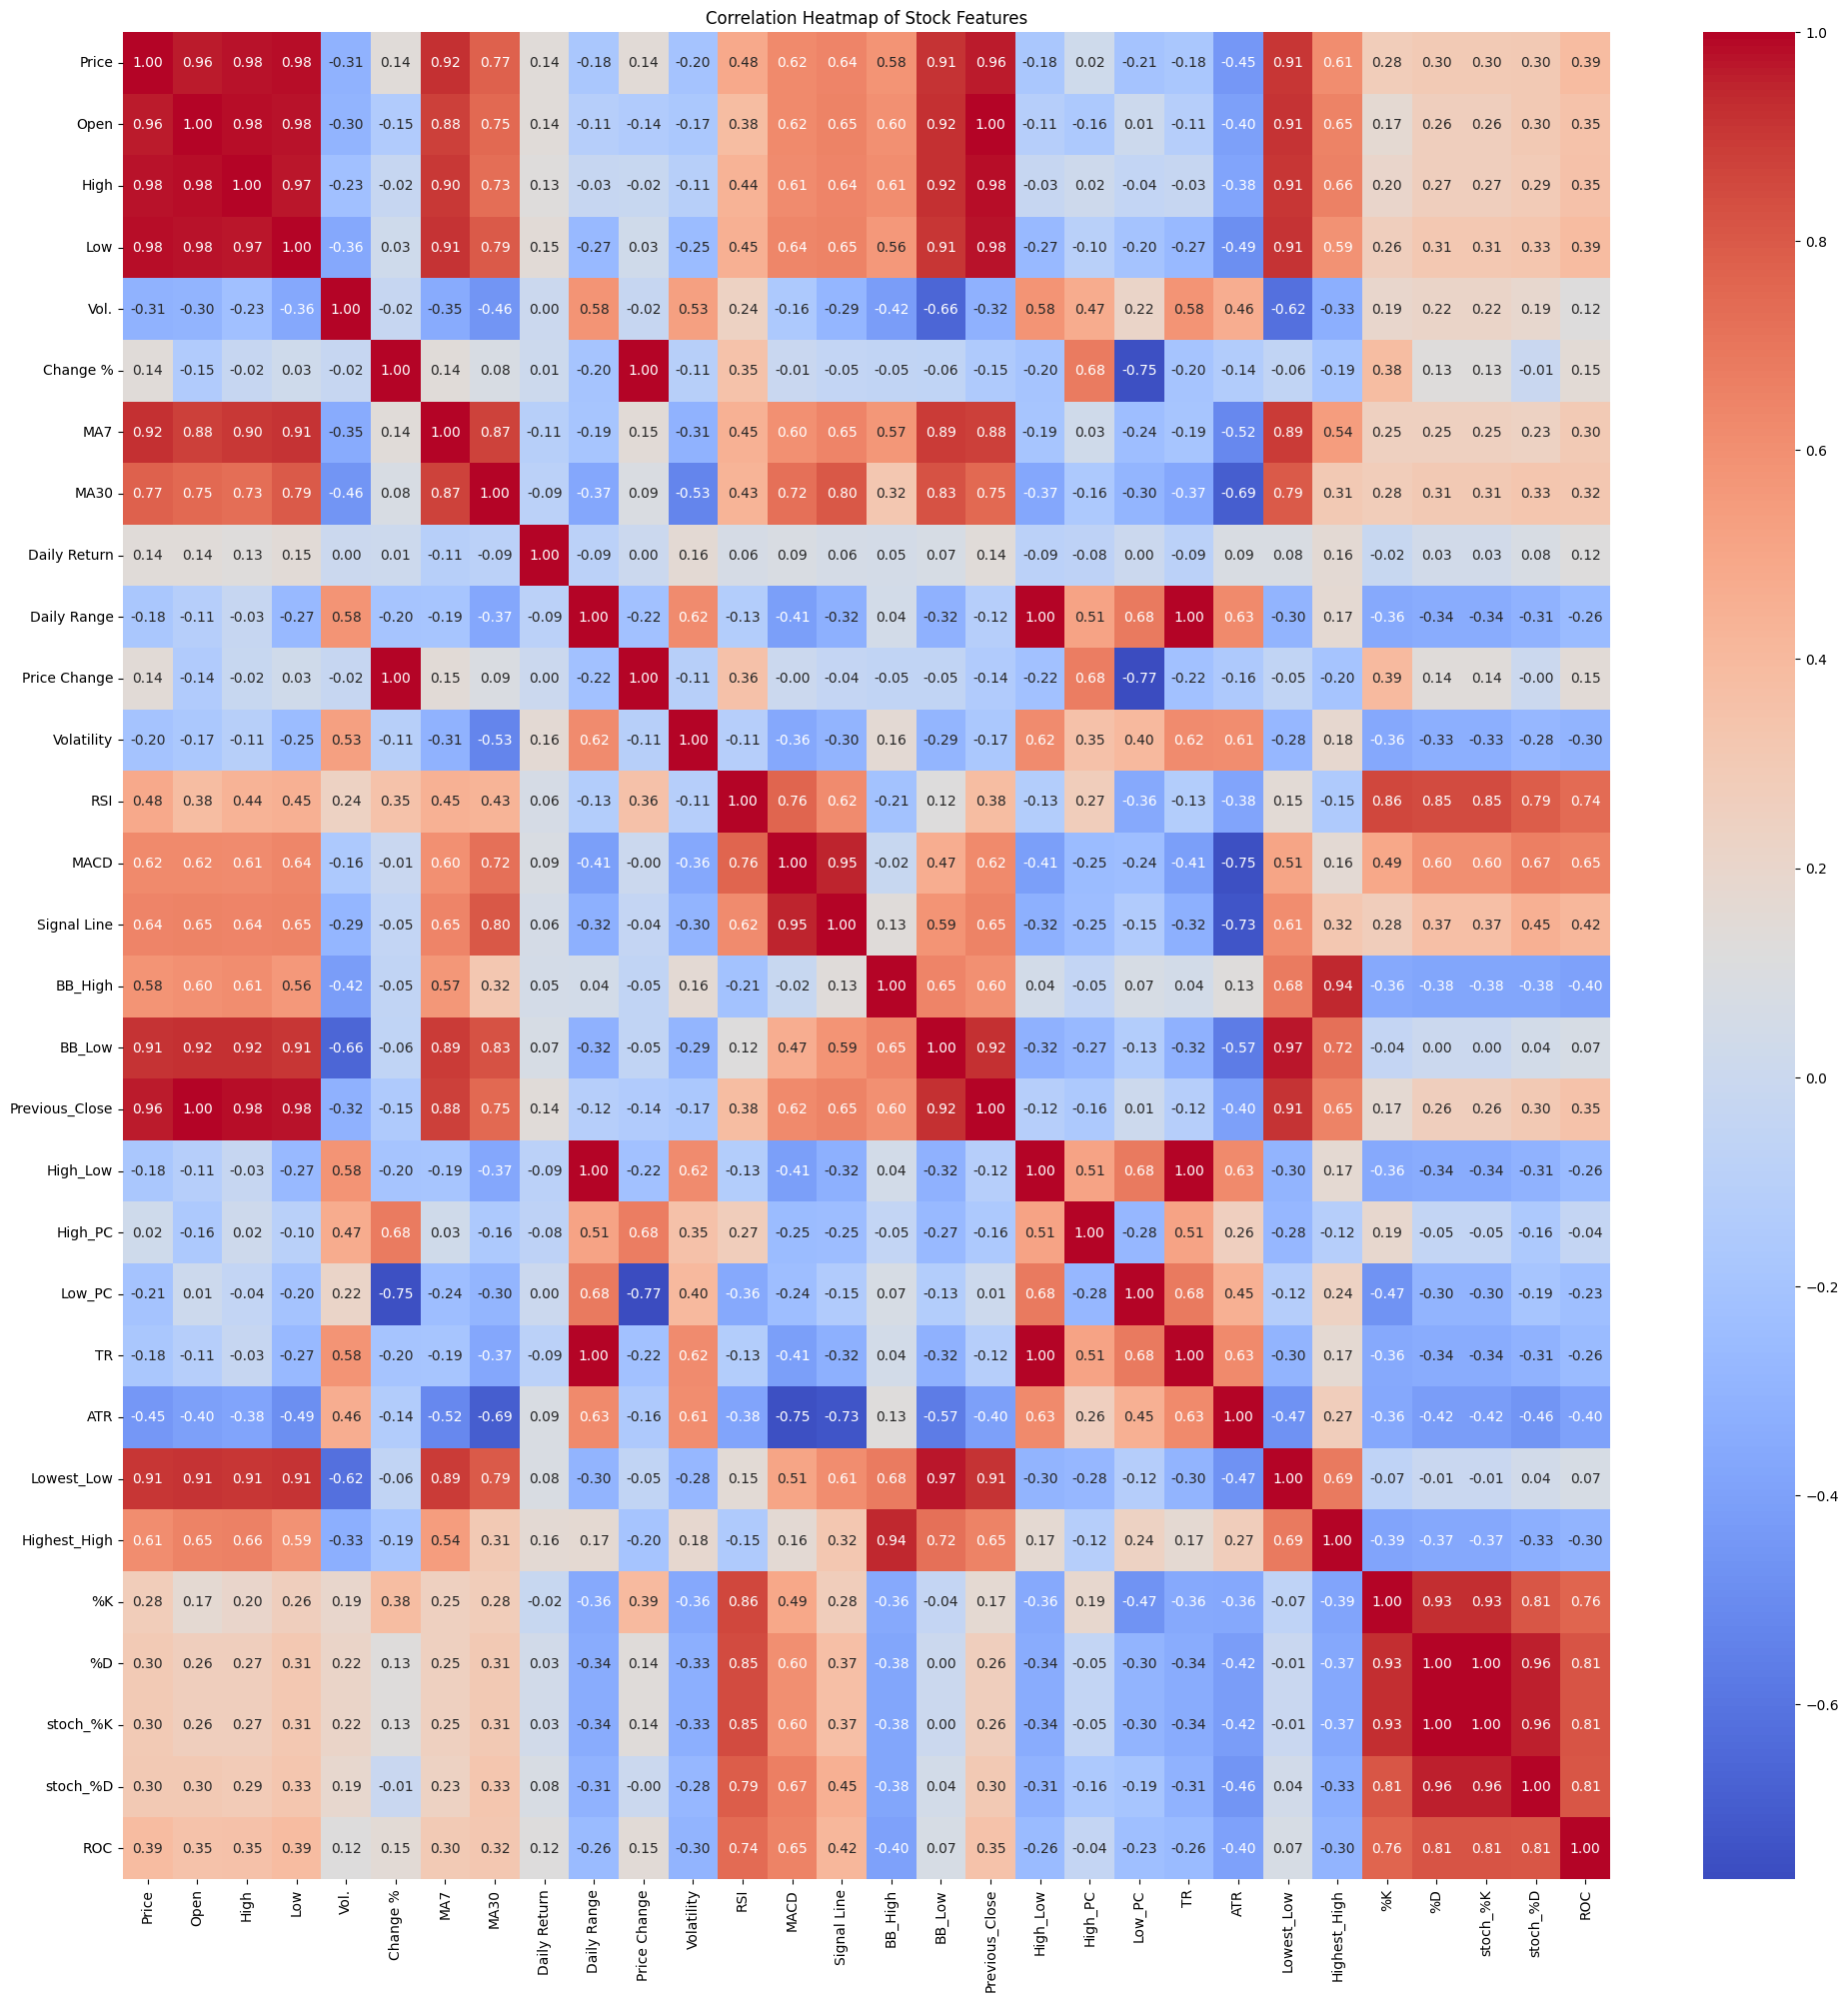

In [667]:
numerical_features= df.select_dtypes(include=['float64']).copy()
corr_matrix = numerical_features.corr()

# Display the correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

plt.figure(figsize=(24, 24))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Stock Features")
plt.show()

#### **Strongly Correlated Groups**


**Price, Open, High, Low, Previous_Close, MA7, MA30, BB_High, BB_Low, Highest_High, Lowest_Low**

- All are above 0.99 with each other, which means they essentially carry the same price information in different forms.


**Daily Range, TR, ATR, High_Low, High_PC, Low_PC**

These columns measure intraday or rolling volatility in various ways:

- Daily Range ≈ High – Low
- TR (True Range) ≈ max of (High_Low, High_PC, Low_PC)
- ATR is the rolling average of TR, leading to strong correlation.


**RSI, %K, and %D**

- The Stochastic Oscillator lines are highly correlated with each other (0.93).
- RSI also has a high correlation (0.83+) with %K and %D.


**MACD and Signal Line**

- Naturally correlated (both are derived from EMAs of Price).
- Show moderate correlation with RSI/Stochastic (0.30–0.55 range).


#### **Notable Individual Correlations**


**Volume (Vol.)**

- Moderately correlated with Price (~0.32).
- Correlation with volatility measures (ATR, TR) is lower (~0.28).


**Change % vs. Price Change**

- Change % (percentage change) and Price Change (absolute difference) have a strong correlation (~0.76), but each tells a different story:
  - Change % normalizes the price move by the previous close.
  - Price Change is the absolute difference (in points).


**Daily Return**

- Weak correlation with most price features (±0.02 to ±0.01 range).
- Some moderate relationships with volatility measures (e.g., High_PC at ~0.33).


### Feature Selection


**Price (closing price)** (Trend/Level).

**Volume (Vol.)** (Market Participation) is only moderately correlated with price and can reveal liquidity/participation info.

**ATR** (Volatility) is a rolling measure of True Range, and typically more robust for modeling.

**RSI** (Momentum) is a classic overbought/oversold measure.

**MACD** (Momentum) captures momentum shifts between short/long EMAs.

**Daily Return (or Change %)** (Short-Term Change).


In [668]:
selected_features = ["Date", "Price", "Vol.", "ATR", "RSI", "MACD", "Daily Return"]

stock = df[selected_features].copy()
print("Missing Values:\n", stock.isnull().sum())
df.dropna(inplace=True)
print("Missing Values:\n", stock.isnull().sum())

Missing Values:
 Date             0
Price            0
Vol.             0
ATR             13
RSI              0
MACD            25
Daily Return     0
dtype: int64
Missing Values:
 Date             0
Price            0
Vol.             0
ATR             13
RSI              0
MACD            25
Daily Return     0
dtype: int64


In [669]:
stock.dropna(inplace=True)
stock.head()

df.dropna(inplace=True)
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA30,Daily Return,...,TR,ATR,Lowest_Low,Highest_High,%K,%D,stoch_%K,stoch_%D,ROC,ROC_decision
205,2024-03-31,26883.39,27559.35,27631.72,26746.24,148320000.0,-2.45,28030.530000,26982.661667,-0.049962,...,885.48,1042.607857,26746.24,33382.51,2.066673,1.569075,1.569075,6.298533,-13.318198,0
204,2024-04-01,28297.17,26883.39,28297.17,26883.39,199760000.0,5.26,28420.970000,26994.042000,0.012988,...,1413.78,1043.380714,26746.24,32746.61,25.847239,9.304637,9.304637,5.479688,-9.641137,0
203,2024-04-02,27934.36,28297.17,28659.08,27934.36,217540000.0,-1.28,28578.637143,26958.384333,-0.000102,...,724.72,933.617857,26746.24,31781.24,23.597219,17.170377,17.170377,9.348030,-10.068676,0
202,2024-04-03,27937.22,27934.36,27978.76,27643.50,141800000.0,0.01,28826.258571,26934.077000,-0.019958,...,335.26,840.770714,26746.24,31781.24,23.654022,24.366160,24.366160,16.947058,-3.967064,0
201,2024-04-04,28506.16,27937.22,28618.34,27937.22,214650000.0,2.04,28882.748571,26920.810000,0.012593,...,681.12,838.039286,26746.24,31065.50,40.745869,29.332370,29.332370,23.622969,-0.591232,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2024-12-19,30526.71,30503.07,30528.42,30211.82,94120000.0,0.08,30078.341429,29773.650000,0.005071,...,316.60,272.862857,30211.82,31232.73,30.844051,38.075828,38.075828,51.619324,-0.333119,0
32,2024-12-22,30372.70,30526.71,30626.63,30372.70,49700000.0,-0.50,29906.697143,29747.918667,0.008444,...,253.93,273.430000,30211.82,31232.73,15.758490,24.314717,24.314717,37.895602,-1.491635,0
31,2024-12-23,30118.38,30372.70,30443.89,30118.38,88370000.0,-0.84,29816.394286,29724.444333,0.004845,...,325.51,288.313571,30118.38,31232.73,0.000000,15.534180,15.534180,25.974909,-2.338522,-1
30,2024-12-24,29973.15,30118.38,30165.45,29810.40,64740000.0,-0.48,29808.122857,29711.684667,-0.001061,...,355.05,286.786429,29810.40,31232.73,11.442492,9.066994,9.066994,16.305297,-3.500780,0


## Create Signals $ Target

### RSI Signals

In [670]:
import numpy as np
import pandas as pd

def apply_rsi_strategy(df, rsi_period=14):
    # Initialize all target columns
    df['RSI_signal'] = 5  # Default / uninitialized
    df['RSI_signal_type'] = ''  # To store the type of signal

    # 1. Overbought/Oversold signals
    upper_threshold = 70
    lower_threshold = 30

    df.loc[(df['RSI'] > lower_threshold) & (df['RSI'].shift(1) <= lower_threshold), 'RSI_signal'] = 1
    df.loc[(df['RSI'] > lower_threshold) & (df['RSI'].shift(1) <= lower_threshold), 'RSI_signal_type'] = 'oversold_bounce'

    df.loc[(df['RSI'] < upper_threshold) & (df['RSI'].shift(1) >= upper_threshold), 'RSI_signal'] = -1
    df.loc[(df['RSI'] < upper_threshold) & (df['RSI'].shift(1) >= upper_threshold), 'RSI_signal_type'] = 'overbought_rejection'

    # 2. 50-level cross signals
    df.loc[(df['RSI'] > 50) & (df['RSI'].shift(1) <= 50), 'RSI_signal'] = 1
    df.loc[(df['RSI'] > 50) & (df['RSI'].shift(1) <= 50), 'RSI_signal_type'] = '50_cross_up'

    df.loc[(df['RSI'] < 50) & (df['RSI'].shift(1) >= 50), 'RSI_signal'] = -1
    df.loc[(df['RSI'] < 50) & (df['RSI'].shift(1) >= 50), 'RSI_signal_type'] = '50_cross_down'

    # 3. Divergences
    for i in range(2, len(df)):
        if (df['Price'].iloc[i] < df['Price'].iloc[i-1] and
            df['RSI'].iloc[i] > df['RSI'].iloc[i-1] and
            df['RSI'].iloc[i-1] < lower_threshold):
            df.at[df.index[i], 'RSI_signal'] = 1
            df.at[df.index[i], 'RSI_signal_type'] = 'bullish_divergence'

        if (df['Price'].iloc[i] > df['Price'].iloc[i-1] and
            df['RSI'].iloc[i] < df['RSI'].iloc[i-1] and
            df['RSI'].iloc[i-1] > upper_threshold):
            df.at[df.index[i], 'RSI_signal'] = -1
            df.at[df.index[i], 'RSI_signal_type'] = 'bearish_divergence'

    # 4. Custom Logic
    df.loc[(df['RSI'] > 70) | ((df['RSI'] >= 30) & (df['RSI'] <= 45)), 'RSI_signal'] = -1
    df.loc[(df['RSI'] > 70) | ((df['RSI'] >= 30) & (df['RSI'] <= 45)), 'RSI_signal_type'] = 'weak_sell'

    df.loc[(df['RSI'] < 30) | ((df['RSI'] >= 35) & (df['RSI'] <= 70)), 'RSI_signal'] = 1
    df.loc[(df['RSI'] < 30) | ((df['RSI'] >= 35) & (df['RSI'] <= 70)), 'RSI_signal_type'] = 'weak_buy'

    df.loc[(df['RSI'] >= 45) & (df['RSI'] <= 55), 'RSI_signal'] = 0
    df.loc[(df['RSI'] >= 45) & (df['RSI'] <= 55), 'RSI_signal_type'] = 'neutral_zone'

    return df

# Apply the strategy
df = apply_rsi_strategy(df)

# Show signals
print(df[['Date', 'Price', 'RSI', 'RSI_signal', 'RSI_signal_type']].tail(20))

# Optional: Filter only rows with signals
signals = df[df['RSI_signal'] != 0]
print(signals[['Date', 'Price', 'RSI', 'RSI_signal', 'RSI_signal_type']])


         Date     Price        RSI  RSI_signal RSI_signal_type
48 2024-11-28  30242.13  42.147928           1        weak_buy
47 2024-12-01  30497.13  46.980826           0    neutral_zone
46 2024-12-02  30525.32  47.502937           0    neutral_zone
45 2024-12-03  30628.74  49.468934           0    neutral_zone
44 2024-12-04  30832.61  53.190418           0    neutral_zone
43 2024-12-05  30839.57  53.316821           0    neutral_zone
42 2024-12-08  31060.51  57.262177           1        weak_buy
41 2024-12-09  31005.12  55.984747           1        weak_buy
40 2024-12-10  30617.83  47.932947           0    neutral_zone
39 2024-12-11  30739.26  50.344331           0    neutral_zone
38 2024-12-12  30795.09  51.457477           0    neutral_zone
37 2024-12-15  30776.00  51.036184           0    neutral_zone
36 2024-12-16  30799.43  51.560373           0    neutral_zone
35 2024-12-17  30601.64  46.987284           0    neutral_zone
34 2024-12-18  30503.07  44.852259           1        w

In [671]:
print(df['RSI_signal'].value_counts())

RSI_signal
 1    100
 0     65
-1     12
Name: count, dtype: int64


### MACD Signals

In [672]:
# file ipython-input-128-74738fe4c1b5
# def apply_macd_strategy(df, fast=12, slow=26, signal=9):
#     # Calculate MACD and Signal Line
#     # Use 'Price' column instead of 'Close'
#     df['EMA_fast'] = df['Price'].ewm(span=fast, adjust=False).mean()
#     df['EMA_slow'] = df['Price'].ewm(span=slow, adjust=False).mean()
#     df['MACD'] = df['EMA_fast'] - df['EMA_slow']
#     df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()

#     # MACD signal logic:
#     # Buy when MACD crosses above the signal line
#     # Sell when MACD crosses below the signal line
#     df['MACD_decision'] = 0  # 1: Buy, -1: Sell, 0: Hold/Neutral

#     # Generate decisions
#     df.loc[(df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1)), 'MACD_decision'] = 1
#     df.loc[(df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1)), 'MACD_decision'] = -1

#     return df
# def apply_macd_strategy(df, fast=12, slow=26, signal=9):
#     # 1. حساب EMA السريع والبطيء
#     df['EMA_fast'] = df['Price'].ewm(span=fast, adjust=False).mean()
#     df['EMA_slow'] = df['Price'].ewm(span=slow, adjust=False).mean()

#     # 2. حساب خط MACD و Signal Line
#     df['MACD'] = df['EMA_fast'] - df['EMA_slow']
#     df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()

#     # 3. حساب Histogram
#     df['MACD_histogram'] = df['MACD'] - df['MACD_signal']

#     # 4. إضافة عمود القرار النصي
#     def macd_decision(row):
#         if row['MACD'] > row['MACD_signal'] and row['MACD_histogram'] > 0:
#             return 'BUY'
#         elif row['MACD'] < row['MACD_signal'] and row['MACD_histogram'] < 0:
#             return 'SELL'
#         else:
#             return 'NEUTRAL'

#     df['MACD_decision'] = df.apply(macd_decision, axis=1)

#     return df
def apply_macd_strategy(df, fast=12, slow=26, signal=9):
    # 1. حساب EMA السريع والبطيء
    df['EMA_fast'] = df['Price'].ewm(span=fast, adjust=False).mean()
    df['EMA_slow'] = df['Price'].ewm(span=slow, adjust=False).mean()

    # 2. حساب خط MACD و Signal Line
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()

    # 3. حساب Histogram
    df['MACD_histogram'] = df['MACD'] - df['MACD_signal']

    # 4. توليد القرارات الرقمية بناءً على المنطق
    def macd_decision(row):
        if row['MACD'] > row['MACD_signal'] and row['MACD_histogram'] > 0:
            return 1     # BUY
        elif row['MACD'] < row['MACD_signal'] and row['MACD_histogram'] < 0:
            return -1    # SELL
        else:
            return 0     # NEUTRAL

    df['MACD_decision'] = df.apply(macd_decision, axis=1)

    return df

df = apply_macd_strategy(df)
print(df[['Price', 'MACD', 'MACD_signal', 'MACD_histogram', 'MACD_decision']].tail())



       Price        MACD  MACD_signal  MACD_histogram  MACD_decision
33  30526.71  -30.207336   -16.166398      -14.040937             -1
32  30372.70  -51.372600   -23.207639      -28.164962             -1
31  30118.38  -87.657265   -36.097564      -51.559701             -1
30  29973.15 -126.671777   -54.212407      -72.459371             -1
29  30005.00 -153.254409   -74.020807      -79.233602             -1


In [673]:
print(df['MACD_decision'].value_counts())


MACD_decision
 1    100
-1     76
 0      1
Name: count, dtype: int64


### Stochastic Signal

In [674]:
# def apply_stochastic_strategy(df):
#     df['Stochastic_signal'] = 5  # Default / uninitialized
#     df['Stochastic_signal_type'] = ''

#     for i in range(1, len(df)):
#         # تقاطع صاعد (BUY)
#         if df['%K'].iloc[i] > df['%D'].iloc[i] and df['%K'].iloc[i-1] <= df['%D'].iloc[i-1]:
#             df.at[df.index[i], 'Stochastic_signal'] = 1
#             df.at[df.index[i], 'Stochastic_signal_type'] = 'Buy'

#         # تقاطع هابط (SELL)
#         elif df['%K'].iloc[i] < df['%D'].iloc[i] and df['%K'].iloc[i-1] >= df['%D'].iloc[i-1]:
#             df.at[df.index[i], 'Stochastic_signal'] = -1
#             df.at[df.index[i], 'Stochastic_signal_type'] = 'Sell'

#         # منطقة حيادية
#         elif 45 <= df['%K'].iloc[i] <= 55 and 45 <= df['%D'].iloc[i] <= 55:
#             df.at[df.index[i], 'Stochastic_signal'] = 0
#             df.at[df.index[i], 'Stochastic_signal_type'] = 'Neutral'

#     return df


def apply_stochastic_strategy(df):
    df['Stochastic_signal'] = 0  # Neutral by default
    df['Stochastic_signal_type'] = 'Neutral'

    for i in range(1, len(df)):
        k_now = df['%K'].iloc[i]
        d_now = df['%D'].iloc[i]
        k_prev = df['%K'].iloc[i - 1]
        d_prev = df['%D'].iloc[i - 1]

        # 🟢 BUY Signal (Oversold Cross)
        if k_now > d_now and k_prev <= d_prev and k_now < 20:
            df.at[df.index[i], 'Stochastic_signal'] = 1
            df.at[df.index[i], 'Stochastic_signal_type'] = 'Buy (Oversold)'

        # 🔴 SELL Signal (Overbought Cross)
        elif k_now < d_now and k_prev >= d_prev and k_now > 80:
            df.at[df.index[i], 'Stochastic_signal'] = -1
            df.at[df.index[i], 'Stochastic_signal_type'] = 'Sell (Overbought)'

        # ⚪ Otherwise: keep Neutral (0)
        else:
            df.at[df.index[i], 'Stochastic_signal'] = 0
            df.at[df.index[i], 'Stochastic_signal_type'] = 'Neutral'

    return df

# تطبيق الاستراتيجية
df = apply_stochastic_strategy(df)

# طباعة النتائج
print(df[['Date', 'Price', '%K', '%D', 'Stochastic_signal', 'Stochastic_signal_type']].tail(20))

# إشارات فقط
signals = df[df['Stochastic_signal'] != 0]
print(signals[['Date', 'Price', '%K', '%D', 'Stochastic_signal', 'Stochastic_signal_type']])


         Date     Price         %K         %D  Stochastic_signal  \
48 2024-11-28  30242.13  23.503407  10.225180                  0   
47 2024-12-01  30497.13  36.029256  19.844221                  0   
46 2024-12-02  30525.32  39.586192  33.039618                  0   
45 2024-12-03  30628.74  47.573195  41.062881                  0   
44 2024-12-04  30832.61  61.830339  49.663242                  0   
43 2024-12-05  30839.57  67.413534  58.939023                  0   
42 2024-12-08  31060.51  88.277017  72.506963                  0   
41 2024-12-09  31005.12  84.506630  80.065727                  0   
40 2024-12-10  30617.83  58.143872  76.975840                  0   
39 2024-12-11  30739.26  66.409590  69.686697                  0   
38 2024-12-12  30795.09  70.209927  64.921130                  0   
37 2024-12-15  30776.00  68.910475  68.509997                  0   
36 2024-12-16  30799.43  70.505350  69.875251                  0   
35 2024-12-17  30601.64  57.041822  65.485882   

In [675]:
print(df['Stochastic_signal'].value_counts())

Stochastic_signal
 0    159
-1     14
 1      4
Name: count, dtype: int64


### Stochastic-RSI Signal

In [676]:
def calculate_stochastic_rsi(df, rsi_period=14, k_period=14, d_period=3):
    # لازم يكون عندك عمود RSI الأول
    df['RSI_min'] = df['RSI'].rolling(window=k_period).min()
    df['RSI_max'] = df['RSI'].rolling(window=k_period).max()

    df['StochRSI_%K'] = 100 * ((df['RSI'] - df['RSI_min']) / (df['RSI_max'] - df['RSI_min']))
    df['StochRSI_%D'] = df['StochRSI_%K'].rolling(window=d_period).mean()

    return df


In [677]:
def apply_stochrsi_strategy(df):
    df['StochRSI_signal'] = 0  # Neutral by default
    df['StochRSI_signal_type'] = 'Neutral'

    for i in range(1, len(df)):
        k_now = df['StochRSI_%K'].iloc[i]
        d_now = df['StochRSI_%D'].iloc[i]
        k_prev = df['StochRSI_%K'].iloc[i - 1]
        d_prev = df['StochRSI_%D'].iloc[i - 1]

        # 🟢 BUY Signal
        if k_now > d_now and k_prev <= d_prev and k_now < 20:
            df.at[df.index[i], 'StochRSI_signal'] = 1
            df.at[df.index[i], 'StochRSI_signal_type'] = 'Buy (StochRSI Oversold)'

        # 🔴 SELL Signal
        elif k_now < d_now and k_prev >= d_prev and k_now > 80:
            df.at[df.index[i], 'StochRSI_signal'] = -1
            df.at[df.index[i], 'StochRSI_signal_type'] = 'Sell (StochRSI Overbought)'

    return df

# 2. احسب Stochastic RSI
df = calculate_stochastic_rsi(df)

# 3. طبق استراتيجية الإشارات
df = apply_stochrsi_strategy(df)

# 4. طباعة النتائج
print(df[['Date', 'RSI', 'StochRSI_%K', 'StochRSI_%D', 'StochRSI_signal', 'StochRSI_signal_type']].tail(20))

# 5. إشارات فقط
signals = df[df['StochRSI_signal'] != 0]
print(signals[['Date', 'RSI', 'StochRSI_%K', 'StochRSI_%D', 'StochRSI_signal', 'StochRSI_signal_type']])


         Date        RSI  StochRSI_%K  StochRSI_%D  StochRSI_signal  \
48 2024-11-28  42.147928    29.893583    10.430731                0   
47 2024-12-01  46.980826    47.624486    25.839357                0   
46 2024-12-02  47.502937    54.297057    43.938376                0   
45 2024-12-03  49.468934    61.861116    54.594220                0   
44 2024-12-04  53.190418    91.057433    69.071869                0   
43 2024-12-05  53.316821   100.000000    84.306183                0   
42 2024-12-08  57.262177   100.000000    97.019144                0   
41 2024-12-09  55.984747    94.648780    98.216260               -1   
40 2024-12-10  47.932947    60.919373    85.189384                0   
39 2024-12-11  50.344331    71.020788    75.529647                0   
38 2024-12-12  51.457477    75.683815    69.207992                0   
37 2024-12-15  51.036184    73.918995    73.541199                0   
36 2024-12-16  51.560373    76.114850    75.239220                0   
35 202

In [678]:
print(df['StochRSI_signal'].value_counts())

StochRSI_signal
 0    161
-1      9
 1      7
Name: count, dtype: int64


### ATR Signal

In [679]:
def apply_atr_strategy(df):
    # Decision logic: based on ATR trend change
    def atr_decision(row, prev_row):
        if np.isnan(row['ATR']) or np.isnan(prev_row['ATR']):
            return 0  # No signal

        if row['ATR'] > prev_row['ATR'] * 1.1:
            return -1  # Sell / high volatility
        elif row['ATR'] < prev_row['ATR'] * 0.95:
            return 1   # Buy / low volatility
        else:
            return 0   # Hold

    # Apply signal generation
    decisions = [0]  # First row has no previous to compare
    for i in range(1, len(df)):
        decisions.append(atr_decision(df.iloc[i], df.iloc[i - 1]))

    df['ATR_decision'] = decisions

    return df
df = apply_atr_strategy(df)
print(df[["Date","ATR",'ATR_decision']])


          Date          ATR  ATR_decision
205 2024-03-31  1042.607857             0
204 2024-04-01  1043.380714             0
203 2024-04-02   933.617857             1
202 2024-04-03   840.770714             1
201 2024-04-04   838.039286             0
..         ...          ...           ...
33  2024-12-19   272.862857             0
32  2024-12-22   273.430000             0
31  2024-12-23   288.313571             0
30  2024-12-24   286.786429             0
29  2024-12-25   285.405714             0

[177 rows x 3 columns]


In [680]:
print(df[['ATR_decision']].value_counts())

ATR_decision
 0              143
 1               27
-1                7
Name: count, dtype: int64


### ADX Signal

In [681]:
import pandas as pd
import numpy as np

def apply_adx_strategy(df, period=14):
    # Calculate the True Range (TR)
    df['TR'] = np.maximum.reduce([
        df['High'] - df['Low'],
        abs(df['High'] - df['Price'].shift(1)),
        abs(df['Low'] - df['Price'].shift(1))
    ])

    # Calculate +DM and -DM
    df['+DM'] = np.where(
        (df['High'] - df['High'].shift(1)) > (df['Low'].shift(1) - df['Low']),
        np.maximum(df['High'] - df['High'].shift(1), 0),
        0
    )
    df['-DM'] = np.where(
        (df['Low'].shift(1) - df['Low']) > (df['High'] - df['High'].shift(1)),
        np.maximum(df['Low'].shift(1) - df['Low'], 0),
        0
    )

    # Smooth the TR, +DM, -DM
    df['TR_smooth'] = df['TR'].rolling(window=period).sum()
    df['+DM_smooth'] = df['+DM'].rolling(window=period).sum()
    df['-DM_smooth'] = df['-DM'].rolling(window=period).sum()

    # Calculate the DI
    df['+DI'] = 100 * (df['+DM_smooth'] / df['TR_smooth'])
    df['-DI'] = 100 * (df['-DM_smooth'] / df['TR_smooth'])

    # Calculate the DX
    df['DX'] = 100 * abs(df['+DI'] - df['-DI']) / (df['+DI'] + df['-DI'])

    # ADX is smoothed DX
    df['ADX'] = df['DX'].rolling(window=period).mean()

    # Generate Signal
    def adx_decision(row):
        if row['ADX'] >= 20:  # Trend is strong enough
            if row['+DI'] > row['-DI']:
                return 1    # BUY
            elif row['-DI'] > row['+DI']:
                return -1   # SELL
        return 0            # NEUTRAL/HOLD

    df['ADX_decision'] = df.apply(adx_decision, axis=1)

    return df

# Example usage
df = apply_adx_strategy(df)
print(df[['High', 'Low', 'Price', '+DI', '-DI', 'ADX', 'ADX_decision']].tail())
print(df[['ADX_decision']].value_counts())

        High       Low     Price        +DI        -DI        ADX  \
33  30528.42  30211.82  30526.71  24.015466  25.772235  20.497405   
32  30626.63  30372.70  30372.70  22.004326  25.718779  16.719899   
31  30443.89  30118.38  30118.38  20.868400  30.691782  13.829546   
30  30165.45  29810.40  29973.15  11.945674  38.525931  14.953381   
29  30164.71  29973.15  30005.00  11.253404  38.712309  16.798758   

    ADX_decision  
33            -1  
32             0  
31             0  
30             0  
29             0  
ADX_decision
 1              77
-1              57
 0              43
Name: count, dtype: int64


### Target signal

In [682]:
# التأكد إن الأعمدة موجودة وكلها أرقام
signal_columns = ['RSI_signal', 'MACD_decision', 'Stochastic_signal', 'ATR_decision', 'ADX_decision','ROC_decision']

# نستخدم .mode() لو عايز الأكثر تكرارًا، لكن الأغلبية الحقيقية بنحسبها كالتالي:
def majority_vote(row):
    signals = [row[col] for col in signal_columns if row[col] in [-1, 0, 1]]
    if not signals:
        return 0  # لو مفيش إشارات واضحة
    return int(np.sign(sum(signals)))  # + = buy, - = sell, 0 = neutral

df['Combined_signal'] = df.apply(majority_vote, axis=1)


In [683]:
print(df['Combined_signal'].value_counts())

Combined_signal
 1    103
-1     50
 0     24
Name: count, dtype: int64


In [684]:
def apply_change_signal(df):
    # تأكد إن العمود 'Change %' من نوع float (لأنه ممكن يكون فيه علامة % كنص)
    df['target'] = df['Change %'].astype(str).str.replace('%', '').astype(float)

    # إنشاء العمود الجديد بناءً على الشروط
    df['target'] = df['target'].apply(
        lambda x: 1 if x > 0.5 else (-1 if x < -0.5 else 0)
    )

    return df

df = apply_change_signal(df)

In [685]:
print(df['target'].value_counts())

target
 0    68
 1    63
-1    46
Name: count, dtype: int64


In [686]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(df['target'], df['Combined_signal'])
print(f"Accuracy: {accuracy:.2f}")

print(classification_report(df['target'], df['Combined_signal'], target_names=["Sell (-1)", "Neutral (0)", "Buy (1)"]))

wrong_predictions = df[df['target'] != df['Combined_signal']]
print(wrong_predictions[['Date', 'target', 'Combined_signal']])



Accuracy: 0.38
              precision    recall  f1-score   support

   Sell (-1)       0.34      0.37      0.35        46
 Neutral (0)       0.38      0.13      0.20        68
     Buy (1)       0.41      0.67      0.51        63

    accuracy                           0.38       177
   macro avg       0.37      0.39      0.35       177
weighted avg       0.38      0.38      0.35       177

          Date  target  Combined_signal
203 2024-04-02      -1                1
202 2024-04-03       0                1
200 2024-04-07      -1                1
197 2024-04-16      -1                1
195 2024-04-18      -1                0
..         ...     ...              ...
36  2024-12-16       0                1
35  2024-12-17      -1                1
34  2024-12-18       0                1
33  2024-12-19       0               -1
30  2024-12-24       0               -1

[109 rows x 3 columns]


In [687]:
# Select features and target
all_features = ["Open", "High", "Low", "Price", "Vol.", "RSI","RSI_signal"]


In [688]:
print(df["RSI_signal"].value_counts())

RSI_signal
 1    100
 0     65
-1     12
Name: count, dtype: int64


In [689]:
df[all_features]

,Open,High,Low,Price,Vol.,RSI,RSI_signal
205,27559.35,27631.72,26746.24,26883.39,148320000.0,34.104995,-1
204,26883.39,28297.17,26883.39,28297.17,199760000.0,44.759978,1
203,28297.17,28659.08,27934.36,27934.36,217540000.0,42.845343,1
202,27934.36,27978.76,27643.50,27937.22,141800000.0,42.866090,1
201,27937.22,28618.34,27937.22,28506.16,214650000.0,46.988623,0
...,...,...,...,...,...,...,...
33,30503.07,30528.42,30211.82,30526.71,94120000.0,45.491950,0
32,30526.71,30626.63,30372.70,30372.70,49700000.0,42.068339,1
31,30372.70,30443.89,30118.38,30118.38,88370000.0,37.102734,1
30,30118.38,30165.45,29810.40,29973.15,64740000.0,34.591719,-1


In [690]:
# Number of features (columns)
num_features = df[all_features].shape[1]
print(f"Number of features: {num_features}")

# Number of samples (rows)
num_samples = df[all_features].shape[0]
print(f"Number of samples: {num_samples}")

# Column names
print("Feature names:", df[all_features].columns.tolist())

# Data types of features
print("Data types:\n", df[all_features].dtypes)

# Summary statistics
print("Summary statistics:\n", df[all_features].describe())


Number of features: 7
Number of samples: 177
Feature names: ['Open', 'High', 'Low', 'Price', 'Vol.', 'RSI', 'RSI_signal']
Data types:
 Open          float64
High          float64
Low           float64
Price         float64
Vol.          float64
RSI           float64
RSI_signal      int64
dtype: object
Summary statistics:
                Open          High           Low         Price          Vol.  \
count    177.000000    177.000000    177.000000    177.000000  1.770000e+02   
mean   29181.184068  29459.279718  28968.820000  29195.001299  1.717328e+08   
std     1828.384825   1760.576503   1901.126771   1825.297241  7.357394e+07   
min    24448.730000  25296.020000  24193.870000  24448.730000  4.970000e+07   
25%    27934.360000  28174.670000  27766.270000  27937.220000  1.125200e+08   
50%    29706.700000  30072.100000  29528.790000  29846.040000  1.580300e+08   
75%    30658.000000  30884.120000  30552.820000  30658.000000  2.201600e+08   
max    31866.060000  32184.680000  31720.500

In [691]:
df

,Date,Price,Open,High,Low,Vol.,Change %,MA7,MA30,Daily Return,...,TR_smooth,+DM_smooth,-DM_smooth,+DI,-DI,DX,ADX,ADX_decision,Combined_signal,target
205,2024-03-31,26883.39,27559.35,27631.72,26746.24,148320000.0,-2.45,28030.530000,26982.661667,-0.049962,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,-1,-1
204,2024-04-01,28297.17,26883.39,28297.17,26883.39,199760000.0,5.26,28420.970000,26994.042000,0.012988,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1
203,2024-04-02,27934.36,28297.17,28659.08,27934.36,217540000.0,-1.28,28578.637143,26958.384333,-0.000102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,-1
202,2024-04-03,27937.22,27934.36,27978.76,27643.50,141800000.0,0.01,28826.258571,26934.077000,-0.019958,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
201,2024-04-04,28506.16,27937.22,28618.34,27937.22,214650000.0,2.04,28882.748571,26920.810000,0.012593,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2024-12-19,30526.71,30503.07,30528.42,30211.82,94120000.0,0.08,30078.341429,29773.650000,0.005071,...,3820.08,917.41,984.52,24.015466,25.772235,3.528521,20.497405,-1,-1,0
32,2024-12-22,30372.70,30526.71,30626.63,30372.70,49700000.0,-0.50,29906.697143,29747.918667,0.008444,...,3828.02,842.33,984.52,22.004326,25.718779,7.783343,16.719899,0,0,0
31,2024-12-23,30118.38,30372.70,30443.89,30118.38,88370000.0,-0.84,29816.394286,29724.444333,0.004845,...,4036.39,842.33,1238.84,20.868400,30.691782,19.052264,13.829546,0,-1,-1
30,2024-12-24,29973.15,30118.38,30165.45,29810.40,64740000.0,-0.48,29808.122857,29711.684667,-0.001061,...,4015.01,479.62,1546.82,11.945674,38.525931,52.663785,14.953381,0,-1,0


# LSTM


In [692]:
# df['target'] = df['target'].shift(1)
# df.dropna(inplace=True)  # Drop last row which now has NaN target

In [693]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping  # 👈 إضافة

# Assuming df is your DataFrame
features = ["Price","MA7", "RSI_signal", "MACD_decision",'Stochastic_signal',"ATR_decision","ADX_decision","ROC_decision"]  # Add your feature columns here
target = "Combined_signal"  # Assuming 'target' is the column with your labels

# Extract features and target
X = df[features].values
y = df[target].values

# Encode target (-1,0,1) to (0,1,2) for one-hot encoding
y_encoded = y + 1
y_categorical = to_categorical(y_encoded, num_classes=3)

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences for LSTM
def create_sequences(data, target, sequence_length=10):
    X_seq, y_seq = [], []
    for i in range(len(data) - sequence_length):
        X_seq.append(data[i:i+sequence_length])
        y_seq.append(target[i+sequence_length])  # Predict next step
    return np.array(X_seq), np.array(y_seq)

sequence_length = 7
X_sequences, y_sequences = create_sequences(X_scaled, y_categorical, sequence_length)

# Split into train (80%), validation (10%), test (10%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sequences, y_sequences, test_size=0.2, random_state=42, shuffle=False
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, shuffle=False
)

# Model parameters
n_features = X_train.shape[2]
n_classes = 3

# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(sequence_length, n_features), return_sequences=True),
    Dropout(0.3),  # 👈 زودت Dropout للتقليل من overfitting
    LSTM(32),
    Dropout(0.3),  # 👈
    Dense(32, activation='relu'),
    Dense(n_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0005),  # 👈 قللت learning rate
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,               # 👈 يوقف بعد 10 epochs بدون تحسن
    restore_best_weights=True # 👈 يرجّع أفضل نموذج قبل ما الفاليديشن يخرب
)
# Train with validation data
# تدريب النموذج مع EarlyStopping
history = model.fit(
    X_train, y_train,
    epochs=128,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],  # 👈 هنا استخدمناه
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_18 (LSTM)              (None, 7, 64)             18688     
                                                                 
 dropout_18 (Dropout)        (None, 7, 64)             0         
                                                                 
 lstm_19 (LSTM)              (None, 32)                12416     
                                                                 
 dropout_19 (Dropout)        (None, 32)                0         
                                                                 
 dense_18 (Dense)            (None, 32)                1056      
                                                                 
 dense_19 (Dense)            (None, 3)                 99        
                                                                 
Total params: 32,259
Trainable params: 32,259
Non-trai

In [694]:
from sklearn.metrics import classification_report

# Predict class probabilities
y_pred_probs = model.predict(X_test)

# Convert probabilities to class predictions
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=['Sell (-1)', 'Neutral (0)', 'Buy (1)']))


1/1 [==============================] - 1s 623ms/step
              precision    recall  f1-score   support

   Sell (-1)       0.57      0.80      0.67         5
 Neutral (0)       0.00      0.00      0.00         5
     Buy (1)       0.70      1.00      0.82         7

    accuracy                           0.65        17
   macro avg       0.42      0.60      0.50        17
weighted avg       0.46      0.65      0.54        17



c:\Users\ziadh\anaconda3\envs\tensorGPU\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ziadh\anaconda3\envs\tensorGPU\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ziadh\anaconda3\envs\tensorGPU\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

In [695]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {accuracy:.2f}')

# Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1) - 1  # Convert back to -1,0,1

Test Accuracy: 0.65
1/1 [==============================] - 0s 31ms/step


In [696]:

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Print accuracy as percentage
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 64.71%


In [697]:
# Get the last 'sequence_length' days of data
last_sequence = X_scaled[-sequence_length:]  # Takes the last N days (N=sequence_length)

# Reshape for model input (LSTM expects [samples, timesteps, features])
last_sequence = last_sequence.reshape(1, sequence_length, len(features))  # Shape: (1, 10, 6)

# Make prediction
prediction = model.predict(last_sequence)

# Convert prediction to class (-1, 0, 1)
predicted_class = np.argmax(prediction) - 1  # Converts from (0,1,2) back to (-1,0,1)

# Get prediction probabilities
probabilities = {cls: prob*100 for cls, prob in zip([-1, 0, 1], prediction[0])}

print("\nNext Day RSI Signal Prediction:")
print(f"Predicted Signal: {predicted_class}")
print("Prediction Probabilities:")
print(f"  -1 (Oversold): {probabilities[-1]:.2f}%")
print(f"   0 (Neutral):  {probabilities[0]:.2f}%")
print(f"   1 (Overbought): {probabilities[1]:.2f}%")

1/1 [==============================] - 0s 51ms/step

Next Day RSI Signal Prediction:
Predicted Signal: -1
Prediction Probabilities:
  -1 (Oversold): 88.35%
   0 (Neutral):  2.98%
   1 (Overbought): 8.68%


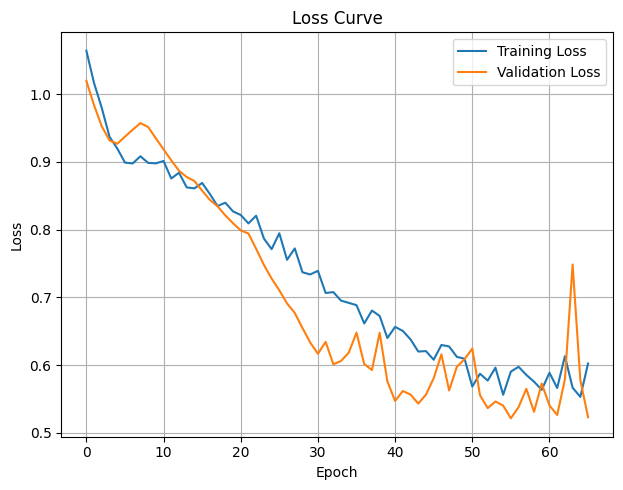

In [698]:
plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()